In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sv3.nn import SvenWrapper, MLP
from sv3.sven import Sven

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

Using device: cpu


### Hessian computation

In [2]:
def get_hessian(model,X,Y,loss_fn):
    params = parameters_to_vector(model.parameters())
    
    param_name_shape_sizes = []
    for name,param in model.named_parameters():
        param_name_shape_sizes.append((name,param.shape,param.numel()))
    
    def loss(params_vector, x, y):
        p = {}
        i = 0
        for (name, shape, size) in param_name_shape_sizes:
            p[name] = params_vector[i:i+size].view(shape)
            i += size
        pred = functional_call(model, p, x)
        L = loss_fn(pred, y)
        print("Loss:", L.item())
        return L

    H = hessian(loss)(params,X,Y).detach()
    return H

def get_hessian_sven(model,X,Y):
    def loss(params, x, y):
        pred = model.func_call(params, x)
        L = model.loss_fn(pred,y).mean()
        print("Loss:", L.item())
        return L
    H = hessian(loss)(model.params,X,Y).detach()
    return H

# Toy linear model hessian

### Define dataset

In [5]:
SEED = 2184
set_seed(SEED)

D = 128
noise_std = 0.1
Ntrain = 10_000
Nval = 1_000
w = torch.randn(1,D)

xtrain = torch.randn(Ntrain, D)
xval = torch.randn(Nval, D)
ytrain = F.linear(xtrain,w) + noise_std * torch.randn(xtrain.shape[0],1)
yval = F.linear(xval,w) + noise_std * torch.randn(xval.shape[0],1)

train_dataset = TensorDataset(xtrain, ytrain)
val_dataset = TensorDataset(xval, yval)


### Define model

In [6]:
SEED = 437438
set_seed(SEED)
model_base = nn.Linear(D, 1, bias=False).to(device)
init_state = copy.deepcopy(model_base.state_dict())
del model_base # free memory

### Training params

In [7]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 100

### Train Adam

In [8]:
model_adam = nn.Linear(D, 1, bias=False).to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-2

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return (pred-y).pow(2).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre = torch.linalg.eigvalsh(H_pre)
del H_pre

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post = torch.linalg.eigvalsh(H_post)
del H_post

Using device cpu


100%|██████████| 100/100 [00:03<00:00, 28.71it/s]


### Train Sven

In [9]:
model_svd = nn.Linear(D, 1, bias=False).to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 4


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven = torch.linalg.eigvalsh(H_pre_sven)
del H_pre_sven

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven = torch.linalg.eigvalsh(H_post_sven)
del H_post_sven

100%|██████████| 100/100 [00:09<00:00, 10.72it/s]


### Compare

(0.0, 100.0)

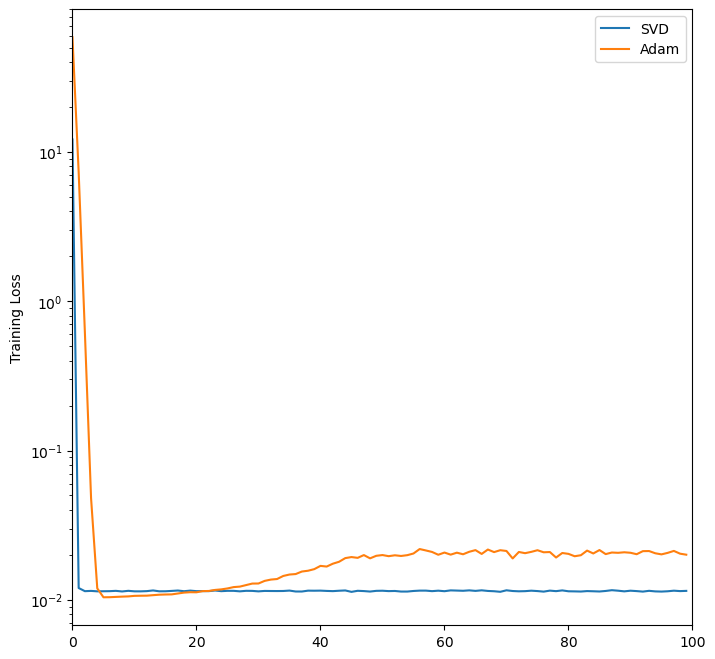

In [12]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,100])

### Look at the Hessian

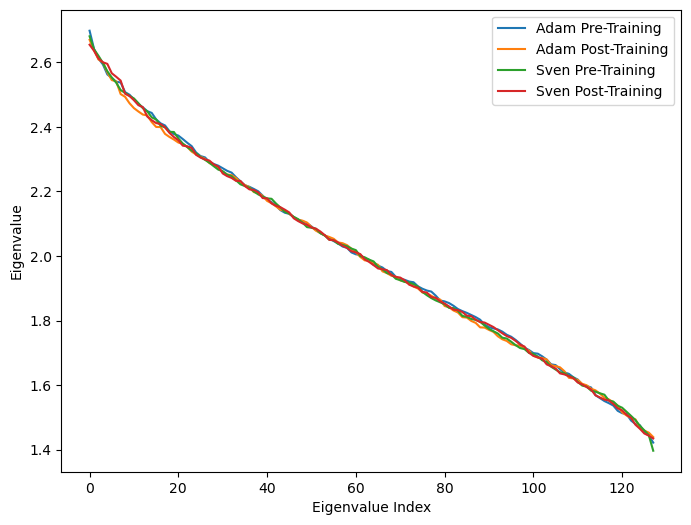

In [11]:
plt.figure(figsize=(8,6))
plt.plot(eigs_pre.numpy()[::-1], label='Adam Pre-Training')
plt.plot(eigs_post.numpy()[::-1], label='Adam Post-Training')
plt.plot(eigs_pre_sven.numpy()[::-1], label='Sven Pre-Training')
plt.plot(eigs_post_sven.numpy()[::-1], label='Sven Post-Training')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.legend()

# Toy 1D dataset

In [30]:
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=12345,n_train=10_000,n_val=2_000,n_test=10_000)
train_dataset = toy_1d.train_dataset
val_dataset = toy_1d.val_dataset

In [31]:
def make_model():
    return MLP(input_dim=1,
               hidden_dims=[16,16],
               output_dim=1)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [32]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 100

### Train Adam

In [33]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-3

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return (pred-y).pow(2).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre = torch.linalg.eigvalsh(H_pre)
#del H_pre

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post = torch.linalg.eigvalsh(H_post)
#del H_post

Loss: 0.9571583867073059
Using device cpu


100%|██████████| 100/100 [00:05<00:00, 18.06it/s]


Loss: 4.918249487673165e-06


### Train Sven

In [34]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 16


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven = torch.linalg.eigvalsh(H_pre_sven)
#del H_pre_sven

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven = torch.linalg.eigvalsh(H_post_sven)
#del H_post_sven

Loss: 0.9571583867073059


100%|██████████| 100/100 [00:25<00:00,  3.87it/s]


Loss: 2.6245138542435598e-06


### Compare

(0.0, 100.0)

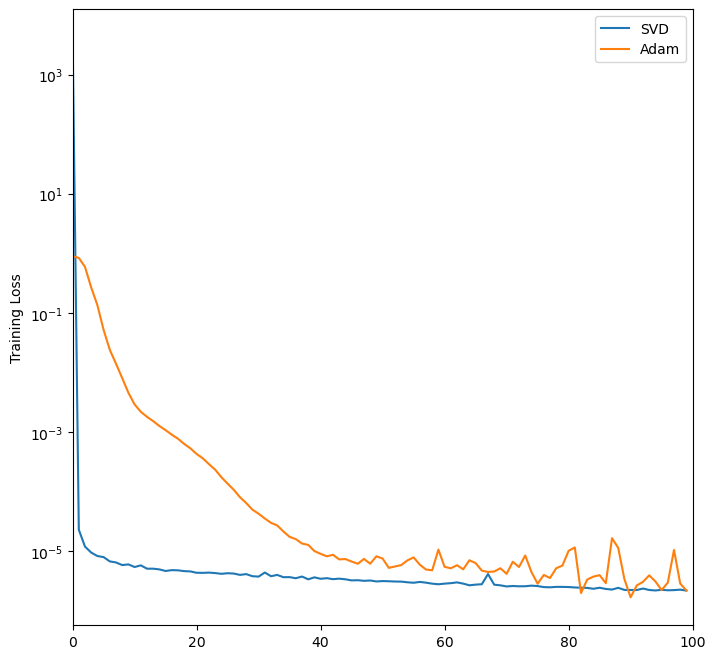

In [35]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,100])

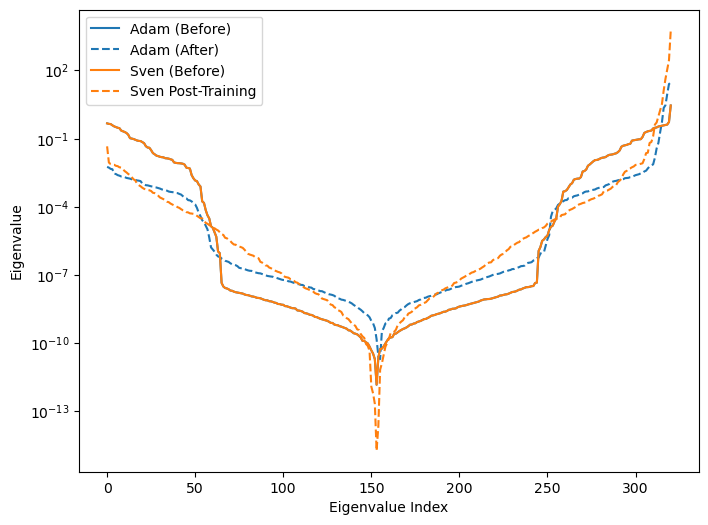

In [45]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre.numpy()), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post.numpy()), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven.numpy()), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven.numpy()), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

# MNIST

In [46]:
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset()
train_dataset = toy_1d.train_dataset[:1000]
val_dataset = toy_1d.val_dataset[:1000]
train_dataset = TensorDataset(train_dataset[0], train_dataset[1])
val_dataset = TensorDataset(val_dataset[0], val_dataset[1])

In [59]:
def make_model():
    return MLP(input_dim=784,
               hidden_dims=[16,16],
               output_dim=10)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [65]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 200

### Train Adam

In [66]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-3

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=10).to(pred)
    return (pred-y).pow(2).sum(dim=1).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre = torch.linalg.eigvalsh(H_pre)
del H_pre

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post = torch.linalg.eigvalsh(H_post)
del H_post

Loss: 1.3024946451187134
Using device cpu


100%|██████████| 200/200 [00:02<00:00, 77.75it/s]


Loss: 0.006854136940091848


### Train Sven

In [67]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    y = F.one_hot(y,num_classes=10).to(pred)
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 64


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven = torch.linalg.eigvalsh(H_pre_sven)
del H_pre_sven

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven = torch.linalg.eigvalsh(H_post_sven)
del H_post_sven

Loss: 1.3024946451187134


100%|██████████| 200/200 [02:05<00:00,  1.60it/s]


Loss: 0.002061625476926565


### Compare

(0.0, 200.0)

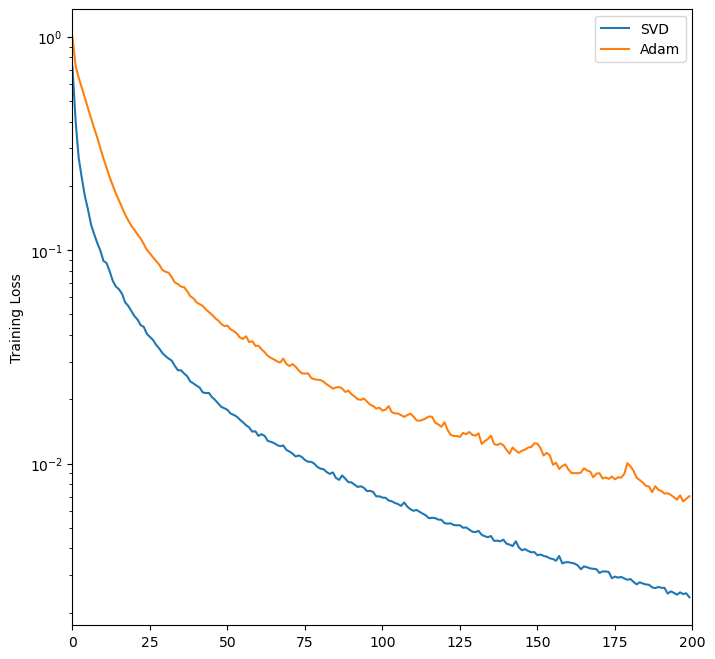

In [69]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,200])

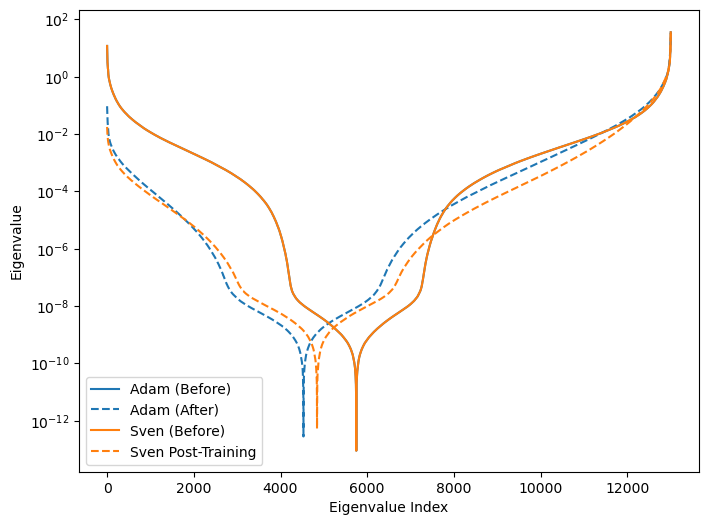

In [73]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre.numpy()), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post.numpy()), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven.numpy()), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven.numpy()), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

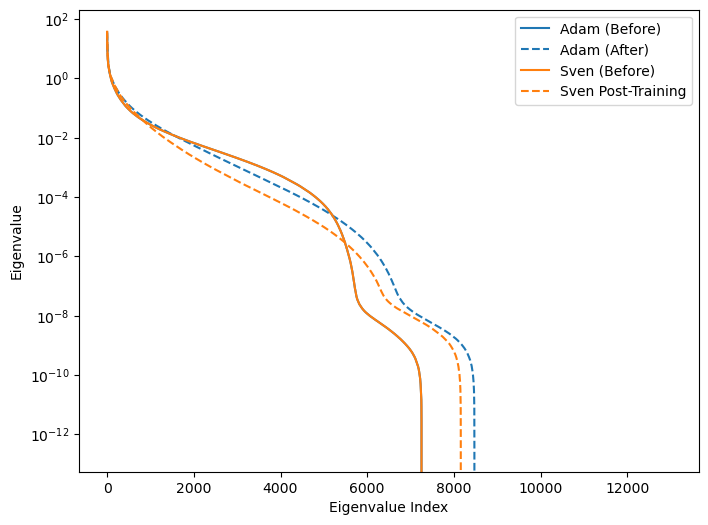

In [71]:
plt.figure(figsize=(8,6))
plt.plot(eigs_pre.numpy()[::-1], label='Adam (Before)',color='C0')
plt.plot(eigs_post.numpy()[::-1], label='Adam (After)',color='C0',linestyle='--')
plt.plot(eigs_pre_sven.numpy()[::-1], label='Sven (Before)',color='C1')
plt.plot(eigs_post_sven.numpy()[::-1], label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

# MNIST cross-entropy

In [84]:
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset()
train_dataset = toy_1d.train_dataset[:10_000]
val_dataset = toy_1d.val_dataset[:10_000]
train_dataset = TensorDataset(train_dataset[0], train_dataset[1])
val_dataset = TensorDataset(val_dataset[0], val_dataset[1])

In [85]:
def make_model():
    return MLP(input_dim=784,
               hidden_dims=[16,16],
               output_dim=10)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [87]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 20

### Train Adam

In [ ]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-3

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return nn.CrossEntropyLoss(reduction='mean')(pred,y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre = torch.linalg.eigvalsh(H_pre)
del H_pre

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post = torch.linalg.eigvalsh(H_post)
del H_post

Loss: 2.323521375656128


### Train Sven

In [81]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return F.cross_entropy(pred, y, reduction='none')

LR_SVD = 0.5
RTOL = 1e-3
K = 64


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven = torch.linalg.eigvalsh(H_pre_sven)
del H_pre_sven

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven = torch.linalg.eigvalsh(H_post_sven)
del H_post_sven

Loss: 2.3184165954589844


100%|██████████| 200/200 [02:02<00:00,  1.64it/s]


Loss: 0.0006532419356517494


### Compare

(0.0, 200.0)

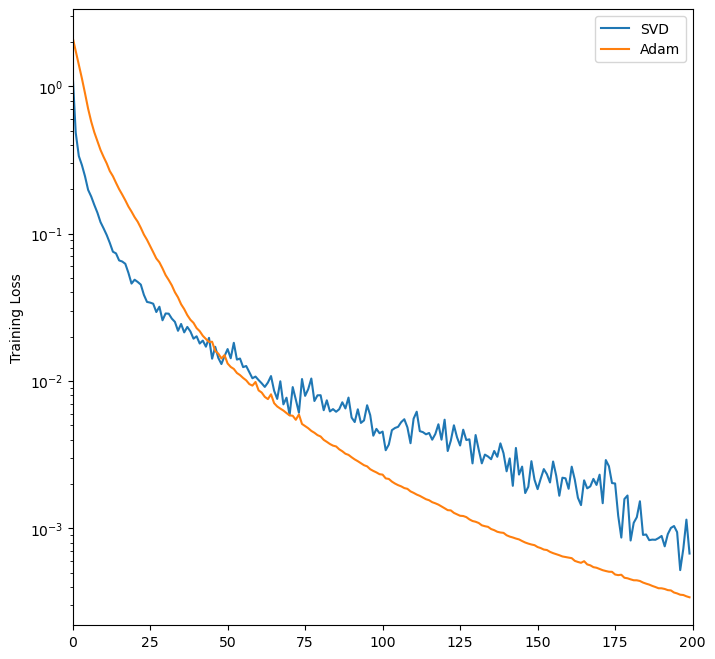

In [82]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,200])

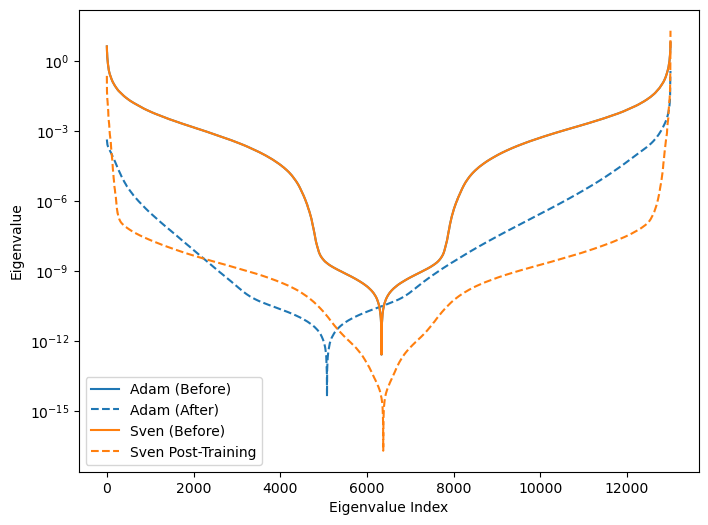

In [83]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre.numpy()), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post.numpy()), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven.numpy()), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven.numpy()), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

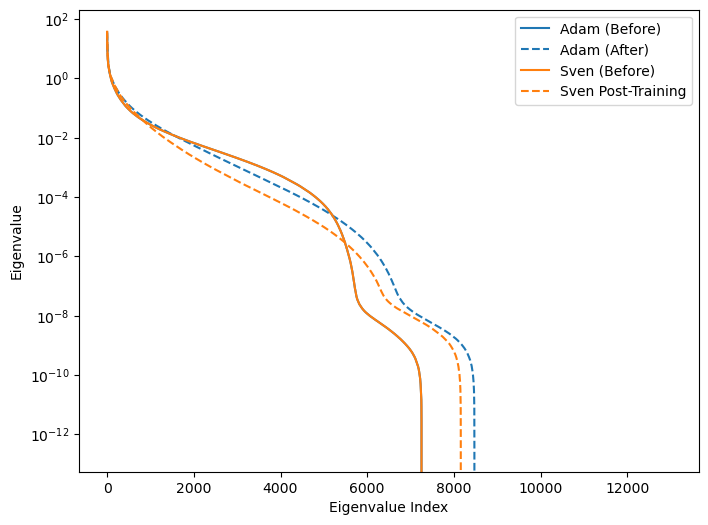

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(eigs_pre.numpy()[::-1], label='Adam (Before)',color='C0')
plt.plot(eigs_post.numpy()[::-1], label='Adam (After)',color='C0',linestyle='--')
plt.plot(eigs_pre_sven.numpy()[::-1], label='Sven (Before)',color='C1')
plt.plot(eigs_post_sven.numpy()[::-1], label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

### thing


In [43]:
def make_model():
    return nn.Sequential(
        nn.Linear(1,4,bias=True),
        nn.LeakyReLU(),
        nn.Linear(4,4),
        nn.LeakyReLU(),
        nn.Linear(4,1,bias=True),
    )

In [44]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = make_model()
model_init = model_init.to(device)
param_name_shape_sizes = []

for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))
    print(name)

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    
    loss = pred.sum()
    return loss

x = torch.randn(1,1)
H = hessian(loss_for_hessian)(params_init, x).detach()

0.weight
0.bias
2.weight
2.bias
4.weight
4.bias


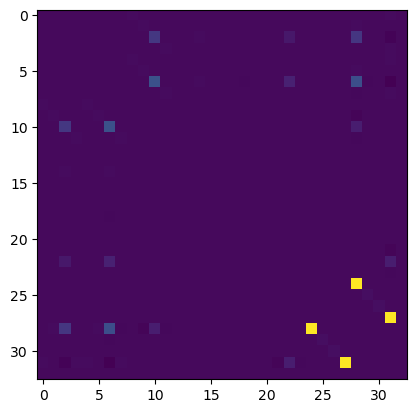

In [45]:
plt.imshow(H)

In [46]:
params_init.shape

torch.Size([33])